In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
dataset_path="/content/drive/MyDrive/dataset1 june 3"

In [3]:
import os

print(os.listdir(dataset_path))

['healthy', 'PESTAL~1', 'sigatoka', 'cordana']


In [4]:
import tensorflow as tf

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path, # Changed from "dataset_path" to dataset_path
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path, # Changed from "dataset_path" to dataset_path
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

Found 1600 files belonging to 4 classes.
Using 1280 files for training.
Found 1600 files belonging to 4 classes.
Using 320 files for validation.


In [5]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

In [6]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

In [8]:
base_model.trainable = False

In [9]:
from tensorflow.keras import models, layers

num_classes = 4 # Define num_classes based on the dataset information

model = models.Sequential([
    layers.Lambda(preprocess_input),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

In [10]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 218s 5s/step - accuracy: 0.7617 - loss: 0.6149 - val_accuracy: 0.9438 - val_loss: 0.1414
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 130s 2s/step - accuracy: 0.9391 - loss: 0.1768 - val_accuracy: 0.9781 - val_loss: 0.0785
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.9656 - loss: 0.1055 - val_accuracy: 0.9719 - val_loss: 0.0930
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - accuracy: 0.9805 - loss: 0.0672 - val_accuracy: 0.9812 - val_loss: 0.0638
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 74s 2s/step - accuracy: 0.9844 - loss: 0.0494 - val_accuracy: 0.9812 - val_loss: 0.0567
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.9891 - loss: 0.0380 - val_accuracy: 0.9812 - val_loss: 0.0480
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - accuracy: 0.9930 - loss: 0.0306 - val_accuracy: 0.9844 - val_loss: 0.0482
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.9969 - loss: 0.0188 - val_accuracy: 0.9875 - val_los

In [12]:
loss, accuracy = model.evaluate(val_ds)

print("Validation Accuracy:", accuracy)

10/10 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.9781 - loss: 0.0598
Validation Accuracy: 0.9781249761581421


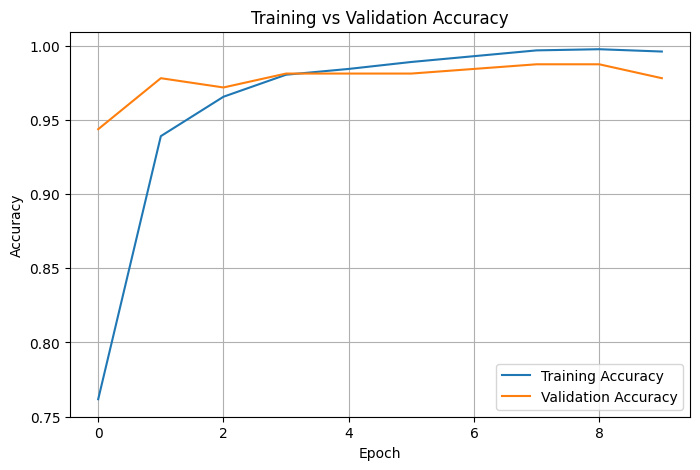

In [13]:
import matplotlib.pyplot as plt

# Accuracy Graph
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()



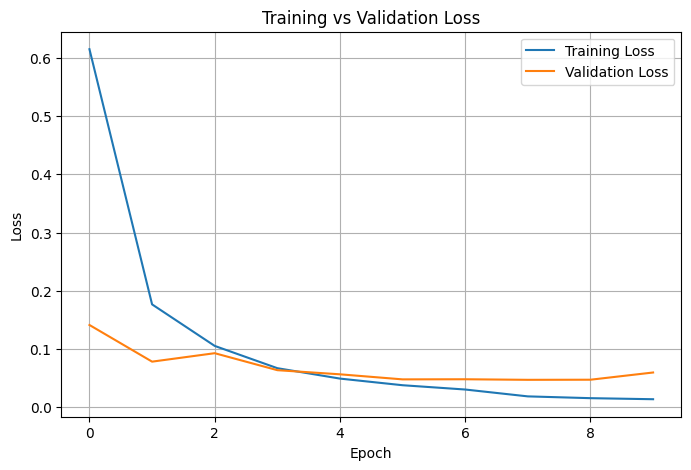

In [14]:
# Loss Graph
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

Confusion Matrix:
[[66  1  3  0]
 [ 0 92  0  0]
 [ 0  0 78  0]
 [ 0  3  0 77]]


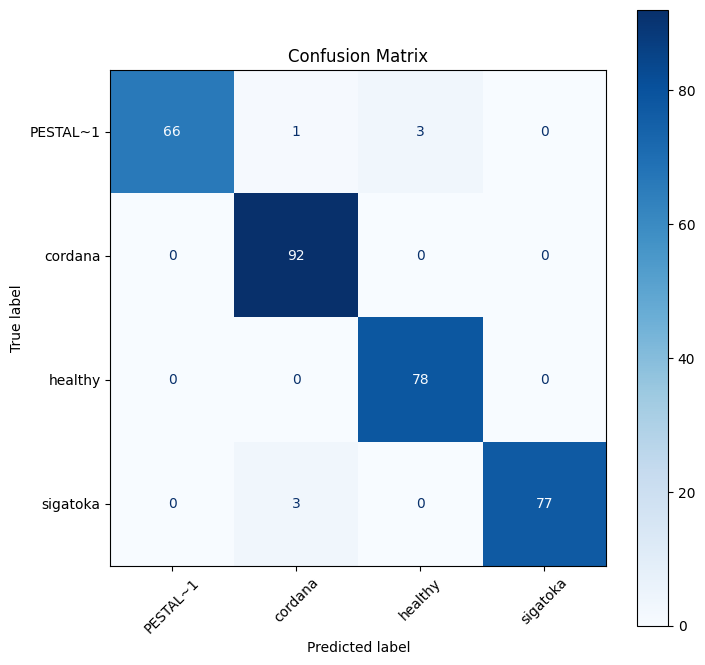

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import os

# Store true and predicted labels
y_true = []
y_pred = []

# Get predictions
for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)

    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

# Display confusion matrix
class_names = sorted(os.listdir(dataset_path))  # Get class names from directory and sort them

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()